# Popularity Recommender: The Baseline

The EDA found that a handful of titles absorb a disproportionate share of ratings, and 18.8% of movies have 20 or fewer. That is the popularity bias a naive model exploits: recommend the same few blockbusters to everyone. This is the first recommender in the lab, built only to be beaten.

## How it works: the mean algorithm

Popularity recommendation is non-personalized. The score of an item comes from the whole population of users, not from the person being recommended to. The standard formulation is the mean algorithm, also called the item average algorithm or the POP algorithm. It is a generalized recommendation algorithm that considers the user interests present in the dataset and scores each item as the average of the ratings given by all the users who rated it. The higher an item's population mean, the higher it ranks for everyone.

The `PopularityRecommender` in this notebook defaults to the rating-count variant, ranking items by how many users rated them. Passing `metric="mean"` selects the item-average scoring the reference describes. The two variants are not the same: count surfaces blockbusters, while mean surfaces niche movies that the few people who saw them rated highly. We demonstrate both below.

Reference: [Popularity Based Recommendation System](https://www.researchgate.net/publication/355773477_Popularity_Based_Recommendation_System), ResearchGate.

## Strengths and weaknesses

**Pros**
- Simple to implement. The whole model is one value per item, computed in a single pass over the ratings.
- Requires no prior user data. No history, no user profiles, no item features.
- Works immediately for new users. A user with no history receives the same sensible list as everyone else.

**Cons**
- Offers zero personalization. Every user gets the same list, so nothing reflects individual taste.
- Ignores niche and individual taste. A user's favorite obscure movies never appear.
- Creates a popularity bias that favors mainstream items while hiding rare ones, the exact bias the EDA measured.

## Setup

Load the data through the shared loader and use the time-based split from the previous notebook, which has zero temporal leakage.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "recommendation_lab").is_dir():
    ROOT = ROOT.parent
    if ROOT == ROOT.parent:
        raise RuntimeError("could not locate recommendation_lab package")
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from recommendation_lab.data.loader import load_ml_1m
from recommendation_lab.data.split import time_base_split
from recommendation_lab.evaluation.evaluate import evaluate_predictions, evaluate_ranking
from recommendation_lab.recommenders.popularity import PopularityRecommender

data = load_ml_1m()
ratings, movies = data["ratings"], data["movies"]
split = time_base_split(ratings)
train, test = split.train, split.test
pd.set_option("display.max_colwidth", 80)
print(f"train: {len(train):,} ratings | test: {len(test):,} ratings")

Dataset 'ml-1m' already present at /Users/kayceejenz/Documents/experiment/recommendation-system-lab/data/ml-1m


train: 797,758 ratings | test: 202,397 ratings


In [2]:
counts = train["movie_id"].value_counts()
means = train.groupby("movie_id")["rating"].mean()

count_top = counts.head(10).index
mean_top = means[counts >= 100].sort_values(ascending=False).head(10).index

titles = movies.set_index("movie_id")["title"]
comparison = pd.DataFrame({
    "top 10 by count (default)": [titles[m] for m in count_top],
    "top 10 by mean (100+ ratings)": [titles[m] for m in mean_top],
})
print(comparison.to_string(index=False))
print(f"shared titles: {len(set(count_top) & set(mean_top))} of 10")

                            top 10 by count (default)                                       top 10 by mean (100+ ratings)
                               American Beauty (1999) Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)
Star Wars: Episode V - The Empire Strikes Back (1980)                                    Shawshank Redemption, The (1994)
            Star Wars: Episode IV - A New Hope (1977)                                               Close Shave, A (1995)
    Star Wars: Episode VI - Return of the Jedi (1983)                                          Usual Suspects, The (1995)
                           Saving Private Ryan (1998)                                               Godfather, The (1972)
                    Terminator 2: Judgment Day (1991)                                          Wrong Trousers, The (1993)
                                 Jurassic Park (1993)                                             Schindler's List (1993)
                        

## The popularity baseline

`PopularityRecommender` ranks every movie by how many times it was rated in train. Its `predict` falls back to the global mean rating, because popularity is a ranking model, not a rating model. The top of its list is exactly the blockbuster tail the EDA flagged.

In [3]:
popularity = PopularityRecommender().fit(train)

top10 = train["movie_id"].value_counts().head(10).reset_index()
top10.columns = ["movie_id", "train_ratings"]
top10 = top10.merge(movies[["movie_id", "title"]], on="movie_id")

print(top10.to_string(index=False))
print()
print(f"global mean rating: {popularity.global_mean:.2f}")

 movie_id  train_ratings                                                 title
     2858           3158                                American Beauty (1999)
     1196           2743 Star Wars: Episode V - The Empire Strikes Back (1980)
      260           2711             Star Wars: Episode IV - A New Hope (1977)
     1210           2642     Star Wars: Episode VI - Return of the Jedi (1983)
     2028           2413                            Saving Private Ryan (1998)
      589           2406                     Terminator 2: Judgment Day (1991)
      480           2394                                  Jurassic Park (1993)
     2571           2328                                    Matrix, The (1999)
     1270           2314                             Back to the Future (1985)
      593           2290                      Silence of the Lambs, The (1991)

global mean rating: 3.62


**Findings:**
The recommender's output is the most-rated movies, period: American Beauty and the Star Wars trilogy at the top. Every user will get almost exactly this list, differing only by which of these they have already seen.

## Rating prediction: RMSE and MAE

Rating metrics ask the model to reproduce the 1-5 star values. Since `predict` is the global mean for every row, the popularity recommender scores identically to a constant predictor that ignores the user entirely.

In [4]:
class GlobalMean:
    """Constant predictor: the training mean for every (user, movie)."""
    name = "global_mean"

    def fit(self, train):
        self.mean = train["rating"].mean()
        return self

    def predict(self, user_id, movie_id):
        return self.mean

scores = pd.DataFrame({
    "popularity": evaluate_predictions(popularity, test),
    "global_mean": evaluate_predictions(GlobalMean().fit(train), test),
}).T
print(scores[["rmse", "mae", "n"]].to_string())

                 rmse       mae         n
popularity   1.146358  0.943925  202397.0
global_mean  1.146358  0.943925  202397.0


**Findings:**
Popularity's RMSE and MAE are byte-for-byte identical to predicting the mean for everyone. Two lessons: rating error does not measure ranking quality, and this baseline has not learned anything user-specific. Later stages report ranking metrics alongside RMSE for exactly this reason.

## Ranking metrics at k=10

For every user, we rank the movies they have not rated, and check how many of the top 10 appear in that user's test set. Five metrics: precision, recall, MAP, NDCG (graded by test rating), and hit rate, macro-averaged over all 6,040 users.

In [5]:
ranking = evaluate_ranking(popularity, train, test, k=10)
for key, value in ranking.items():
    print(f"{key:12s} {value:.4f}")

precision@10 0.1040
recall@10    0.0379
map@10       0.0565
ndcg@10      0.0530
hit_rate@10  0.4548
n_users      6040.0000


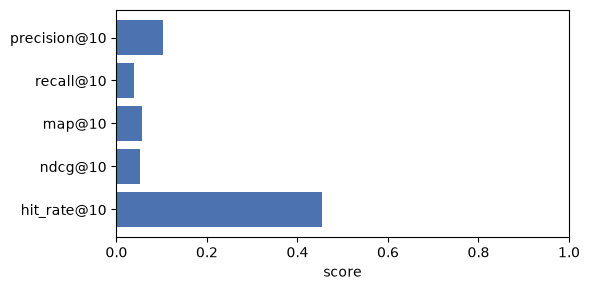

In [6]:
keys = ["precision@10", "recall@10", "map@10", "ndcg@10", "hit_rate@10"]
plt.figure(figsize=(6, 3))
plt.barh(keys[::-1], [ranking[key] for key in keys[::-1]], color="#4C72B0")
plt.xlabel("score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

**Findings:**
Hit rate is deceptively high: the model lands at least one of the user's test movies in the top 10 almost half the time, which is exactly the popularity bias working in its favor. But precision, recall, MAP, and NDCG are all weak, because the list is the same for everyone and cannot rank a user's obscure picks ahead of blockbusters.

## What it recommends

The list varies between users only by which blockbusters they have already rated. Compare two users with very different histories.

In [7]:
def show(user_id, n=5):
    rec = popularity.recommend(user_id, k=n)
    titled = pd.DataFrame({"movie_id": rec}).merge(movies[["movie_id", "title"]], on="movie_id")
    seen = train.loc[train["user_id"] == user_id, "movie_id"].nunique()
    print(f"user {user_id}: {seen} distinct movies rated in train")
    print(titled["title"].to_string(index=False))
    print()

for user_id in [1, 4000]:
    show(user_id)

shared = set(popularity.recommend(1, k=10)) & set(popularity.recommend(4000, k=10))
print(f"shared top-10 between the two users: {len(shared)} of 10")

user 1: 42 distinct movies rated in train
                               American Beauty (1999)
Star Wars: Episode V - The Empire Strikes Back (1980)
    Star Wars: Episode VI - Return of the Jedi (1983)
                    Terminator 2: Judgment Day (1991)
                                 Jurassic Park (1993)

user 4000: 52 distinct movies rated in train
                               American Beauty (1999)
Star Wars: Episode V - The Empire Strikes Back (1980)
            Star Wars: Episode IV - A New Hope (1977)
    Star Wars: Episode VI - Return of the Jedi (1983)
                           Saving Private Ryan (1998)

shared top-10 between the two users: 8 of 10


**Findings:**
The two lists are 8 of 10 identical, the difference being blockbusters one user had already seen. This is the ceiling of popularity: useful for cold-start demos and as a benchmark, but it cannot personalize, so it will never serve long-tail movies. MAP and NDCG pay the price.